In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


#veri okuması 
df = pd.read_csv('Social_Network_Ads.csv')
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

# train - test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

#feature scaling
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

#LogisticRegression
from sklearn.linear_model import LogisticRegression
logr = LogisticRegression(random_state=0)
logr.fit(X_train_scaled,y_train)

y_pred_logr = logr.predict(X_test_scaled)

#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred_logr)
print(cm)



[[65  3]
 [ 8 24]]


In [10]:
#KNN 
from sklearn.neighbors import KNeighborsClassifier 

knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski')
knn.fit(X_train_scaled,y_train)

y_pred_knn = knn.predict(X_test_scaled)

cm = confusion_matrix(y_test,y_pred_knn)

print(cm)

[[64  4]
 [ 3 29]]


C:\Users\KÜBRA\AppData\Local\Temp\ipykernel_27008\2530365517.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == val, 0], X_set[y_set == val, 1],
C:\Users\KÜBRA\AppData\Local\Temp\ipykernel_27008\2530365517.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == val, 0], X_set[y_set == val, 1],
C:\Users\KÜBRA\AppData\Local\Temp\ipykernel_27008\2530365517.py:24: UserWarning:

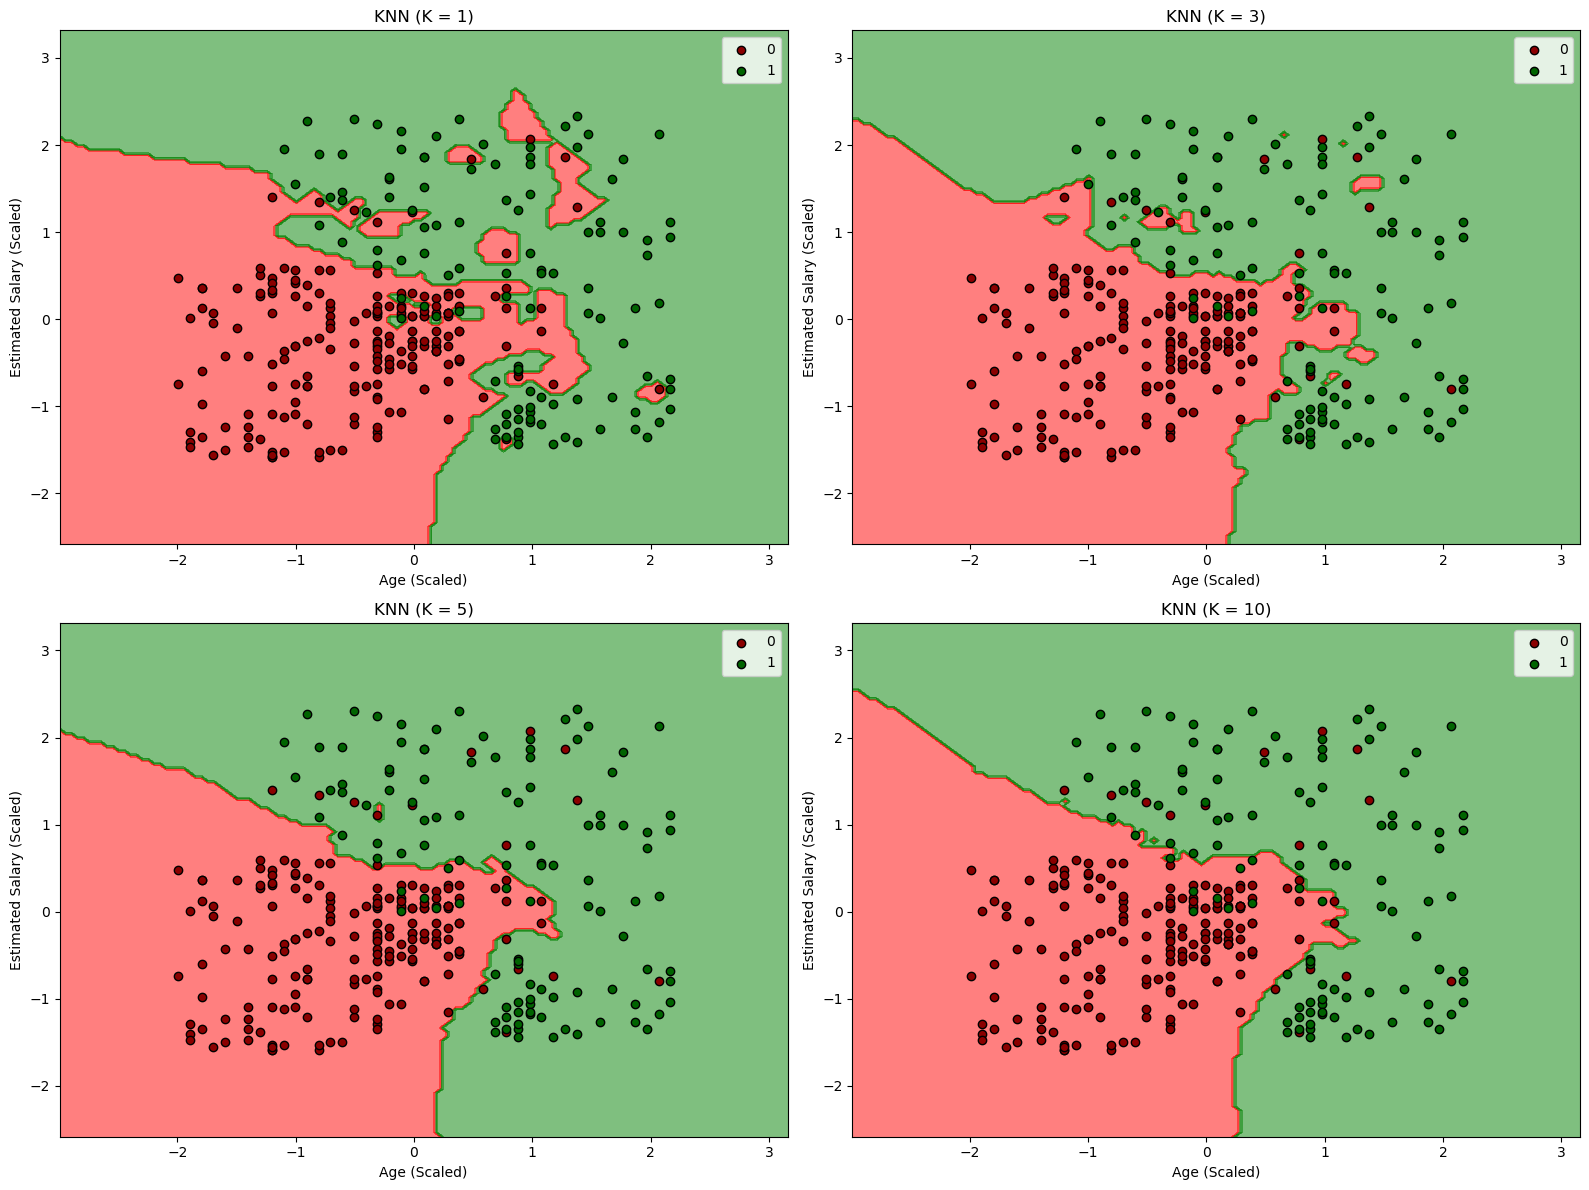

In [14]:
#Visualization
from matplotlib.colors import ListedColormap
k_values=[1,3,5,10]
plt.figure(figsize=(16,12))

for i,k in enumerate(k_values,1):
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski')
    knn.fit(X_train_scaled,y_train)

    # Arka planı boyamak için bir ızgara (grid) oluşturuyoruz
    X_set, y_set = X_train_scaled, y_train
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.05),
                         np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.05))
    
    plt.subplot(2, 2, i)
    # Modelin tahminlerine göre bölgeleri renklendir (Kırmızı: Almaz, Yeşil: Alır)
    plt.contourf(X1, X2, knn.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                 alpha = 0.5, cmap = ListedColormap(('red', 'green')))
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    
    # Gerçek veri noktalarını çiz
    for j, val in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == val, 0], X_set[y_set == val, 1],
                    c = ListedColormap(('darkred', 'darkgreen'))(j), label = val, edgecolors='black')
        
    plt.title(f'KNN (K = {k})')
    plt.xlabel('Age (Scaled)')
    plt.ylabel('Estimated Salary (Scaled)')
    plt.legend()

plt.tight_layout()
plt.show()


